### **📌 Code Overview: Optimizing Renewable Energy Distribution Using Quantum Computing**

## **Table of Contents**
1. **Introduction: Characteristics of Renewable Energy Data**

2. **Quantum Computing Approaches for Optimization**

   - RL-QAOA: Previous Methodology
   
   - Advancements: Constraint RL-QAOA & RL-QAA

3. **Transforming QUBO Problems for RL-QAOA & RL-QAA**

---

## **1️⃣ Introduction: Characteristics of Renewable Energy Data**

Renewable energy sources, such as solar and wind power, exhibit **high variance and volatility** due to their dependence on weather conditions. This natural fluctuation makes energy production 

**less predictable**, creating challenges in ensuring a stable and efficient power grid.

To mitigate this variability and **maximize energy production**, the strategic placement and combination of power plants become crucial. An optimal distribution of renewable energy sources can 

**reduce fluctuations and enhance grid stability**, making this an important optimization problem in the energy sector.

---

In [1]:
### **Solar 1, Wind n**

"""
This section of code processes **a dataset containing one solar energy source and multiple wind energy sources**. Each energy source is **normalized**, and then their **variance** is computed. This variance provides insight into the fluctuations in energy production due to external factors such as weather conditions.

In the dataset:
- **The diagonal elements (self-variance) represent the variance of each energy source individually** and are always **positive**.
- **The off-diagonal elements (cross-variance) capture the variance between different power plants**. 
- These off-diagonal values reflect the **mutual compensatory effect between energy sources**, meaning that certain combinations of power plants can reduce overall variance when selected together.

This information is crucial for **optimizing energy production**, as the goal is to minimize fluctuations by strategically placing and combining power plants.
"""

import json
import numpy as np


# Load precomputed matrices containing variance data
with open(f"./data/matrices5by5.json", "r") as f:
    matrix_5 = json.load(f)

# Convert JSON data to a NumPy array
np.array(matrix_5[0])


array([[ 0.0658492 ,  0.02703027,  0.06400876,  0.05816011, -0.02485329],
       [ 0.02703027,  0.04842342,  0.02703007,  0.02002002, -0.01502243],
       [ 0.06400876,  0.02703007,  0.06320185,  0.05354004, -0.02501211],
       [ 0.05816011,  0.02002002,  0.05354004,  0.06617729, -0.02369893],
       [-0.02485329, -0.01502243, -0.02501211, -0.02369893,  0.08012868]])

In [2]:
## Generate QUBO matrix

"""
This section generates the **QUBO (Quadratic Unconstrained Binary Optimization) matrix** 
from the processed variance data. The QUBO formulation is used to find the optimal 
combination of power plants that minimizes production variance while maximizing energy output.

Key Parameters:
- **hamming_weight (int):** Number of power plants to be selected.
- **lamb (float):** The weight factor controlling sensitivity to variance (n * sigma).
- **Diagonal Adjustment:** Each diagonal element represents a **normalized production value of 1**, 
  and since the optimization process minimizes the function, it is negated. Additionally, 
  the variance values are converted into standard deviation format by dividing by `hamming_weight`.

The generated QUBO matrix serves as the input for quantum optimization algorithms.
"""

from modules.data_process import data_to_QUBO




## Number of power plants to build
hamming_weight = 3

## Sensitivity to variance (n * sigma)
lamb = 3

## Convert variance data into QUBO format
## - Diagonal: Represents energy production (set to -1 for minimization)
## - Off-diagonal: Varience/hamming weight -> standard deviation, standard deviation*lambda -> Confidence Interval
QUBO_matrix = data_to_QUBO(np.array(matrix_5[0]), hamming_weight, lamb)

## Display the generated QUBO matrix
QUBO_matrix


tensor([[-0.9341508 ,  0.02703027,  0.06400876,  0.05816011, -0.02485329],
        [ 0.02703027, -0.95157658,  0.02703007,  0.02002002, -0.01502243],
        [ 0.06400876,  0.02703007, -0.93679815,  0.05354004, -0.02501211],
        [ 0.05816011,  0.02002002,  0.05354004, -0.93382271, -0.02369893],
        [-0.02485329, -0.01502243, -0.02501211, -0.02369893, -0.91987132]], requires_grad=True)

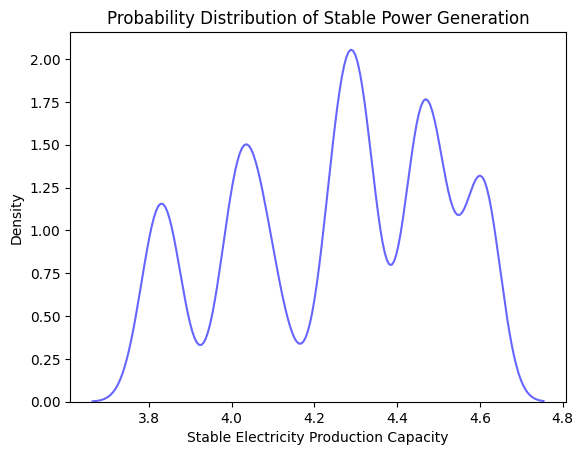

Following results

Best  value   : 4.628477172021516

Average value : 4.254797454757814

Worst value   : 3.788893687434105



In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import json

"""
### **Probability Distribution of Stable Power Generation**

This section of code **visualizes the probability distribution of stable electricity production** 
based on different combinations of power plants. 

**Key Insight:**
- The **expected stable electricity production** when selecting **5 power plants** is **reduced from the ideal 5.0** due to variance.
- In the **worst-case scenario, production can drop below 3.8** due to high fluctuations.
- The **best-case scenario** achieves **near-optimal production**

"""

# Load the precomputed variance data
with open(f"./data/matrices10by10.json", "r") as f:
    matrices_data = json.load(f)

# Define the number of selected power plants and the variance penalty factor
hamming_weight = 5
lamb = 3

# Convert variance data into QUBO format
QUBO_matrix_10 = data_to_QUBO(np.array(matrices_data[0]), hamming_weight, lamb)

# Generate all possible selections of 5 power plants from 10
x_list = list(itertools.combinations([i for i in range(len(QUBO_matrix_10))], hamming_weight))

# Compute the effective stable electricity production for each selection
res_list = []
for x in x_list:
    temp = np.array([0] * len(QUBO_matrix_10))
    temp[list(x)] = 1
    res = np.array(temp) @ QUBO_matrix_10 @ np.array(temp)
    res_list.append(res)

# Sort results for better visualization
res_list = sorted(res_list)

# Plot the probability density of stable electricity production
sns.kdeplot(-np.array(res_list), bw_adjust=0.5, color="blue", alpha=0.6)

plt.xlabel("Stable Electricity Production Capacity")
plt.ylabel("Density")
plt.title("Probability Distribution of Stable Power Generation")
plt.show()

# Print the best, average, and worst-case scenarios
print('Following results\n')
print(f'Best  value   : {-np.min(res_list)}\n')   # Maximum stable production
print(f'Average value : {-np.mean(res_list)}\n')  # Average production across selections
print(f'Worst value   : {-np.max(res_list)}\n')   # Minimum stable production (worst-case)


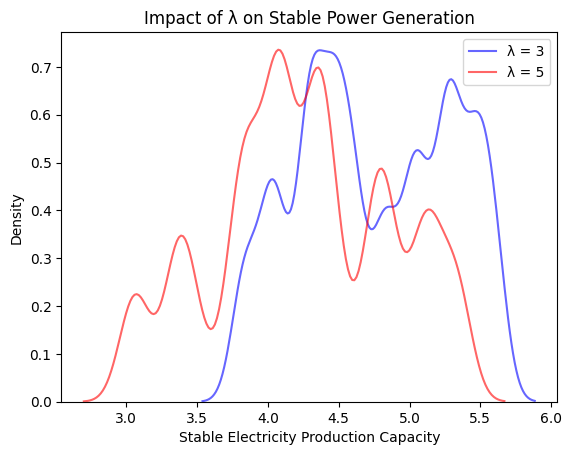

Results for λ = 3

Best  value   : 5.616959161611595

Average value : 4.754797454757813

Worst value   : 3.8057137718889864

Results for λ = 5

Best  value   : 5.3615986026859925

Average value : 4.257995757929689

Worst value   : 3.00952295314831



In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
import itertools
import json
import numpy as np

"""
### **Effect of λ on Stable Electricity Production**

This section of code **analyzes how different values of λ (variance sensitivity factor) affect the probability distribution of stable electricity production**. 

**Process:**
1. **Load variance data** and convert it into QUBO format with different λ values (lamb_1 and lamb_2).
2. **Enumerate all possible selections of 5 power plants** from a total of 10.
3. **Compute the impact of variance** on stable electricity production for different λ values.
4. **Compare the probability distributions**:
   - **Blue curve (λ = 3)**
   - **Red curve (λ = 5)**

**Key Insight:**
- As **λ changes, the distribution and expected values shift unpredictably**, making it difficult to foresee the impact on power generation.
- The **optimal production capacity varies significantly with λ**, making it challenging to consistently achieve **maximum efficiency**.
- **The relationship between λ and production stability is highly non-linear**, further complicating the optimization process.

"""

# Load the precomputed variance data
with open(f"./data/matrices10by10.json", "r") as f:
    matrices_data = json.load(f)

# Define parameters
hamming_weight = 5
lamb_1 = 3  # Variance sensitivity factor 1
lamb_2 = 5  # Variance sensitivity factor 2

# Convert variance data into QUBO format with different λ values
QUBO_matrix_1 = data_to_QUBO(np.array(matrices_data[0]), hamming_weight, lamb_1, relative_diff=[2] + [1] * 9)
QUBO_matrix_2 = data_to_QUBO(np.array(matrices_data[0]), hamming_weight, lamb_2, relative_diff=[2] + [1] * 9)

# Generate all possible selections of 5 power plants from 10
x_list = list(itertools.combinations(range(len(QUBO_matrix_1)), hamming_weight))

# Compute the stable electricity production for each selection under different λ values
res_list_1 = []
res_list_2 = []
for x in x_list:
    temp = np.array([0] * len(QUBO_matrix_1))
    temp[list(x)] = 1
    res_1 = np.array(temp) @ QUBO_matrix_1 @ np.array(temp)
    res_2 = np.array(temp) @ QUBO_matrix_2 @ np.array(temp)
    res_list_1.append(res_1)
    res_list_2.append(res_2)

# Sort results for better visualization
res_list_1 = sorted(res_list_1)
res_list_2 = sorted(res_list_2)

# Plot the probability density of stable electricity production for different λ values
sns.kdeplot(-np.array(res_list_1), bw_adjust=0.5, color="blue", alpha=0.6, label="λ = 3")
sns.kdeplot(-np.array(res_list_2), bw_adjust=0.5, color="red", alpha=0.6, label="λ = 5")

plt.xlabel("Stable Electricity Production Capacity")
plt.ylabel("Density")
plt.title("Impact of λ on Stable Power Generation")
plt.legend()
plt.show()

# Print the best, average, and worst-case scenarios for λ = 3
print('Results for λ = 3\n')
print(f'Best  value   : {-np.min(res_list_1)}\n')   # Maximum stable production
print(f'Average value : {-np.mean(res_list_1)}\n')  # Average production across selections
print(f'Worst value   : {-np.max(res_list_1)}\n')   # Minimum stable production (worst-case)

# Print the best, average, and worst-case scenarios for λ = 5
print('Results for λ = 5\n')
print(f'Best  value   : {-np.min(res_list_2)}\n')   # Maximum stable production
print(f'Average value : {-np.mean(res_list_2)}\n')  # Average production across selections
print(f'Worst value   : {-np.max(res_list_2)}\n')   # Minimum stable production (worst-case)



## **2️⃣ Quantum Computing Approaches for Optimization**
To tackle this optimization challenge, quantum computing offers **powerful algorithms** that can efficiently search for optimal solutions in large and complex parameter spaces. 

### **🔹 RL-QAOA: Previous Approach**
Previously, **Reinforcement Learning-assisted Quantum Approximate Optimization Algorithm (RL-QAOA)** was introduced as a hybrid quantum-AI approach to solving optimization problems.

RL-QAOA leverages reinforcement learning to **RQAOA**, improving solution quality compared to traditional RQAOA.

### **🔹 Advancements: Constraint RL-QAOA & RL-QAA**
Building on RL-QAOA, we introduce **two upgraded methods**:
1. **Constraint RL-QAOA**: A modified version of RL-QAOA that incorporates constraints directly into the optimization process, ensuring feasibility while improving performance.

2. **RL-QAA (Reinforcement Learning-assisted Quantum Annealing Algorithm)**: A novel approach that combines reinforcement learning with quantum annealing, allowing for a more **adaptive** and **efficient** exploration of the solution space.

These advancements aim to enhance **scalability, constraint handling, and solution quality** compared to existing methods.

---

In [11]:
from modules.data_process import add_constraint
import json

"""
### **Applying Soft Constraints to the QUBO Model**

This section of the code **defines a constrained QUBO model** for optimizing energy distribution while incorporating additional constraints.

**Process:**
1. **Load variance data**: Load the dataset representing energy source fluctuations.
2. **Define QUBO parameters**:
   - `λ` (l): The variance sensitivity factor.
   - `hamming_weights`: Number of power plants to be selected.
3. **Generate the QUBO matrix**: Convert variance data into a **QUBO formulation**.
4. **Incorporate Soft Constraints**:
   - Apply **a penalty term** to enforce constraints.
   - Ensure the solution adheres to a predefined **hamming weight constraint (e.g., selecting exactly 4 power plants)**.

**Key Insight:**
- The constraint **limits the number of selected power plants** while optimizing energy stability.
- **Soft constraints** allow flexibility while penalizing solutions that violate the selection condition.

"""

# Load the dataset containing energy fluctuation matrices
with open(f"./data/GeoWindSunMatrices7by7.json", "r") as f:
    matrices_data = json.load(f)

# Define lambda (variance sensitivity factor) and hamming weight (number of selected power plants)
l = 3
hamming_weights = 5

# Convert variance data into QUBO format
QUBO_matrix = data_to_QUBO(np.array(matrices_data[1]), hamming_weights, l)

# Apply Soft Constraints to the QUBO matrix
n = len(QUBO_matrix)  # Number of energy sources
penalty = 1.5  # Penalty factor for constraint violations

# Generate a constraint matrix ensuring exactly 4 power plants are selected
qubo_const = QUBO_matrix + add_constraint(node_hamming_weights=[1] * n, hamming_weights=4) * penalty


In [ ]:
"""
### **Applying Soft Constraints to RL-QAOA and Its Challenges**

This section of the code **applies a Soft Constraint-enhanced QUBO to RL-QAOA** and examines its impact on the learning process.

**1️⃣ Applying Soft Constraints to RL-QAOA**
- The RL-QAOA model is executed using a **QUBO matrix that includes soft constraints**.
- The soft constraint **alters the Hamiltonian structure**, making the **warm-up phase of parameter training more challenging**.

**Key Challenge:**  
- When the **Hamiltonian is compressed during RQAOA**, its shape changes significantly, making it difficult to initialize parameters optimally.

---

**2️⃣ Effect on Training Speed**
- **Training the constraint itself significantly reduces the overall loss**, meaning that after learning the constraint,  
  the system takes **longer to converge when optimizing the original QUBO problem**.
- This results in a **slower overall training process** for our target problem.

"""

from modules.rl_qaoa import RL_QAOA
from modules.data_process import add_constraint
import numpy as np

# Define the stopping condition for RL-QAOA (number of remaining nodes)
n_c = 2  # RL-QAOA halts when this number of nodes remains

# Initialize QAOA parameters
init_params = np.reshape(np.array([ 0.11805387, -0.34618458] * (n - n_c)), -1)

# Define the initial edge temperature matrix for RL-QAOA training
b_vector = np.array([[25.0 * ((n - i) / 10 + 1)] * int(n**2) for i in range(n - n_c)])

# Initialize RL-QAOA with the constraint-enhanced QUBO
rl_qaoa = RL_QAOA(
    qubo_const, 
    n_c=n_c, 
    init_paramter=init_params, 
    b_vector=b_vector, 
    QAOA_depth=1, 
    learning_rate_init=[0.005, 0.50]
)

# Perform brute-force search to obtain the correct solution
rl_qaoa.n_c = n
brute_force_result = rl_qaoa.rqaoa_execute()
correct_ans = brute_force_result[2]
rl_qaoa.n_c = n_c  # Reset n_c to original value

# Train RL-QAOA model with the soft constraint QUBO
rl_qaoa.RL_QAOA(episodes=50, epochs=50, log_interval=5, correct_ans=correct_ans)


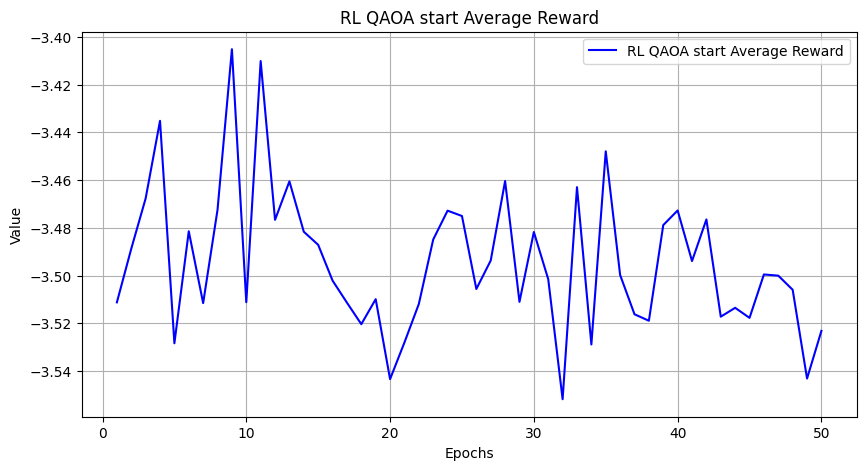

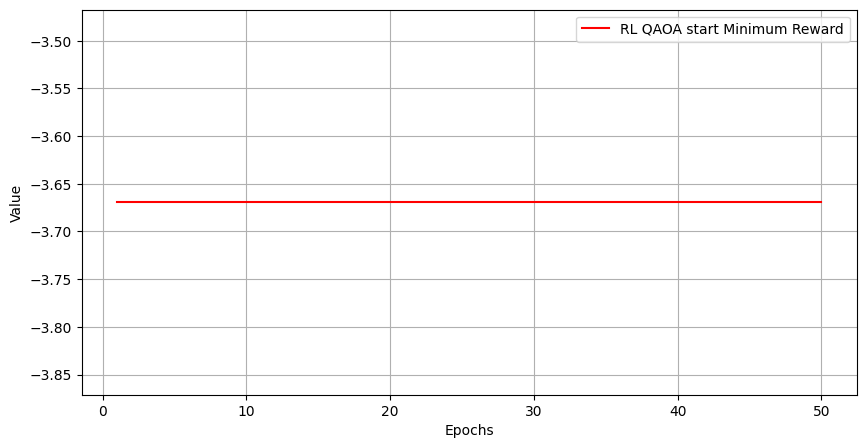

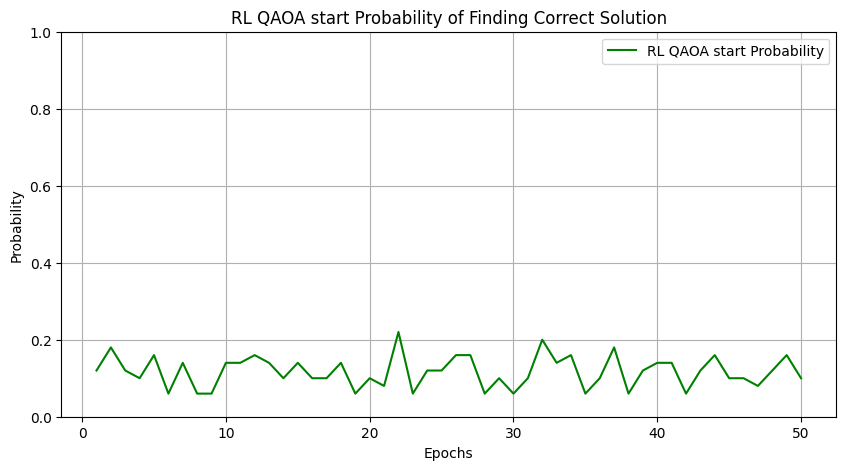

In [ ]:
"""
### **Results of RL-QAOA Optimization**

This section analyzes the performance of RL-QAOA in solving the constrained QUBO problem.

**Key Observations:**
1️⃣ **Probability of Finding the Optimal Solution**  
   - The model exhibits **a certain probability of reaching the optimal solution**,  
     meaning it is **not entirely failing** but struggling to improve further.

2️⃣ **Training Saturation**  
   - After a certain point, **no further learning occurs**, and training plateaus.
   - This suggests that the RL-QAOA model may **get stuck in local optima**.

3️⃣ **Scalability Issues for Larger Problems**  
   - When the problem size increases, **RL-QAOA may fail to guarantee the optimal solution**.
   - This limitation needs to be addressed for practical large-scale applications.

"""


rl_qaoa.plot_result()

In [ ]:
from modules.rl_qaoa import RL_QAOA_constraint
import numpy as np

"""
### **Applying RL-QAOA Constraint for Soft Constraint Handling**

This section introduces an **enhanced RL-QAOA method** designed to handle constraints more effectively  
by treating them **independently** from the main optimization process.

---

### **🔹 Key Improvement: Independent Constraint Handling**
- **Traditional RL-QAOA**: Compresses both the **main Hamiltonian and constraint terms together** during Ising Hamiltonian compression.
- **RL-QAOA Constraint**: **Separates** the constraint Hamiltonian from the main optimization process, ensuring it is updated independently.

H_main(n) + H_constraint(n) -> H_main(n-1) + H_constraint(n-1) where H_main(n-1) = Recursive(H_main(n-1)), H_constraint(n-1) = Constraint_ham(node_weight,hamming_weight)

---

### **🔹 Why This Works?**
From our dataset, we observe that:
- The **RQAOA process naturally modifies node weights and hamming weights**.
- This allows constraints to be **handled independently** without affecting the main optimization.

---

### **🔹 Advantages of This Approach**
1️⃣ **Stronger Parameter Initialization**  
   - Since each Hamiltonian behaves similarly to a **soft constraint**,  
     the **initial QAOA parameters** produce more **effective results**.

2️⃣ **Avoids Over-Focus on Constraint Learning**  
   - Only solutions that **satisfy constraints** contribute to learning.  
   - This prevents **excessive focus on learning constraints** rather than the optimization problem itself.

"""

# Define the number of nodes in the system
n = len(QUBO_matrix)

# Create the QUBO matrix (constraints will be handled independently during training)
qubo = np.array(QUBO_matrix)

# Define the stopping condition for RL-QAOA (number of remaining nodes)
n_c = 2

# Initialize QAOA parameters
init_params = np.reshape(np.array([ 0.11805387, -0.34618458] * (n - n_c)), -1)

# Define the initial edge temperature matrix for RL-QAOA training
b_vector = np.array([[25.0] * int(n**2) for i in range(n - n_c)])

# Initialize RL-QAOA with independent constraint handling
# Additional terms: hamming_weight and penalty
rl_qaoa_const = RL_QAOA_constraint(
    qubo, 
    n_c=n_c, 
    init_paramter=init_params, 
    b_vector=b_vector, 
    QAOA_depth=1, 
    hamming_weight=hamming_weights, 
    penalty=1.5, 
    learning_rate_init=[0.005, 0.50]
)

# Perform brute-force search to obtain the correct solution
rl_qaoa_const.n_c = n
brute_force_result = rl_qaoa_const.rqaoa_execute()
correct_ans = brute_force_result[2]
rl_qaoa_const.n_c = n_c  # Reset n_c to original value

# Execute RL-QAOA training with constraint handling
rl_qaoa_const.RL_QAOA(episodes=50, epochs=50, log_interval=5, correct_ans=correct_ans)


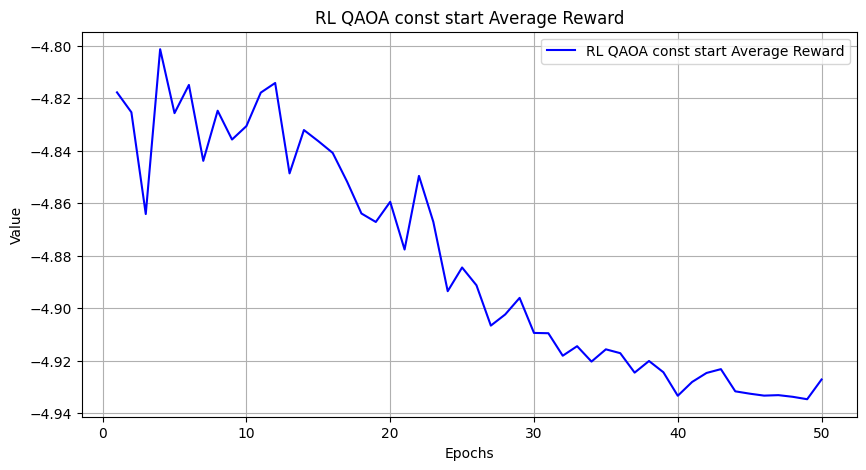

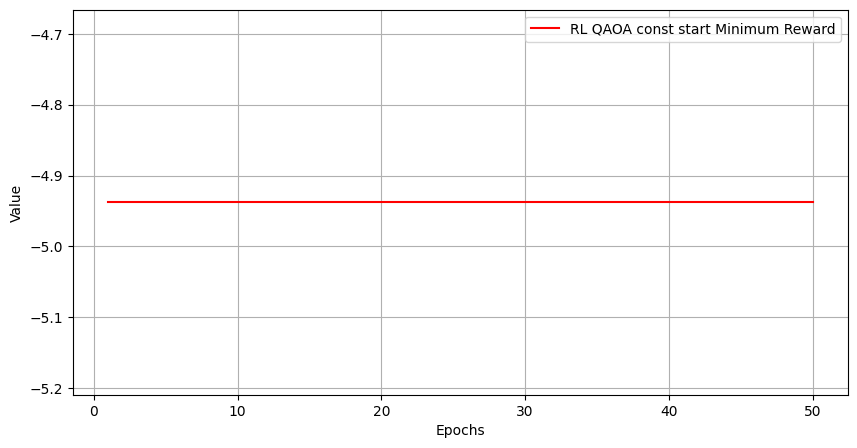

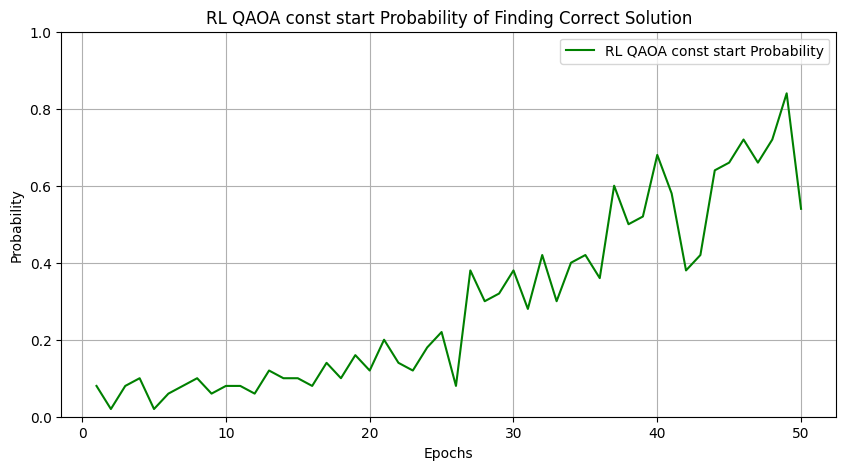

In [ ]:
"""
### **Results of RL-QAOA Constraint Optimization**

This section evaluates the performance of **RL-QAOA with independent constraint handling**.

**Key Observations:**
1️⃣ **Higher Probability of Selecting the Optimal Solution**  
   - Compared to **standard RL-QAOA**, this method significantly **increases the likelihood of reaching the optimal solution**.
   - The improved initialization and independent constraint updates **enhance the search efficiency**.

2️⃣ **Effectiveness of Independent Constraint Handling**  
   - By **separating the constraint Hamiltonian from the main optimization**,  
     the system better **preserves constraint validity** throughout the optimization process.
   - This suggests that applying constraints **independently** can be a more effective strategy when solving **constraint QUBO problems**.

"""

# Plot the results of RL-QAOA constraint optimization
rl_qaoa_const.plot_result()


Quantum adiabatic simulation

기존의 중성원자의 배치만으로는 모든 QUBO문제의 hamiltonian을 완벽하게 구성할 수 없다.

connectivity와 그 값 자체가 거리만으로 구현 불가능한 조합들이 있기 때문에 그러한 조합들을 넘어 adiabatic하게 

general한 QUBO를 돌릴 수 있는 방법이 선행 연구에서 제시되었고, 우리는 그러한 방법이 제시됐을 때 즉 실제 큐비트가 다음과 같은

방법론을 통해 작동했었을 때의 고전적인 시뮬레이션 결과를 보이기 위하여 general QUBO 시뮬레이션 코드를 작성하였다.



In [1]:
## 기존 pulser


import numpy as np
import matplotlib.pyplot as plt
from pulser import Pulse, Sequence, Register
from pulser_simulation import QutipEmulator
from pulser.devices import MockDevice as DigitalAnalogDevice
from pulser.waveforms import InterpolatedWaveform
from scipy.optimize import minimize
from scipy.spatial.distance import pdist, squareform


def plot_distribution(C,title):
    C = dict(sorted(C.items(), key=lambda item: item[1], reverse=True))
    plt.figure(figsize=(12, 6))
    plt.xlabel("bitstrings")
    plt.ylabel("counts")
    plt.bar(C.keys(), C.values(), width=0.5)
    plt.xticks(rotation="vertical")
    plt.title(title)
    plt.show()



Q = np.array([[-3.1       ,  1.07945442,  1.02944084],
       [ 1.07945442, -3.1       ,  1.03790122],
       [ 1.02944084,  1.03790122, -3.1       ]])

coords = np.array([[ 6.70357789, -0.16668682],
        [-4.27552378,  6.9535855 ],
        [-5.02704345, -6.19668303]])

qubits = {f"q{i}": coord for (i, coord) in enumerate(coords)}
reg = Register(qubits)

# We choose a median value between the min and the max
Omega = np.median(Q[Q > 0].flatten())
delta_0 = -5  # just has to be negative
delta_f = -delta_0  # just has to be positive
T = 8000  # time in ns, we choose a time long enough to ensure the propagation of information in the system

In [2]:
## 기존 pulser
adiabatic_pulse = Pulse(
    InterpolatedWaveform(T, [1e-9, Omega, 1e-9]),
    InterpolatedWaveform(T, [delta_0, 0, delta_f]),
    0,
)
seq = Sequence(reg, DigitalAnalogDevice)
seq.declare_channel("ising", "rydberg_global")
seq.add(adiabatic_pulse, "ising")

simul = QutipEmulator.from_sequence(seq)
results = simul.run()
final = results.get_final_state()
count_dict = results.sample_final_state(100000)


In [3]:
## Our simulation

from modules.pulse_simulator import Pulse_simulation
import pennylane as qml

pulse_sim = Pulse_simulation(Q,amplitude=[[1e-9, Omega, 1e-9] for i in range(len(Q))],detuning=[[delta_0, 0, delta_f] for i in range(len(Q))],duration=8000,step_time=50)


dev = qml.device("default.qubit", wires=len(Q))
@qml.qnode(dev)
def circuit():
    pulse_sim.simulate_time_evolution()
    return qml.probs(wires=range(len(Q)))
final_state_expectations = circuit() #측정할 기저 설정

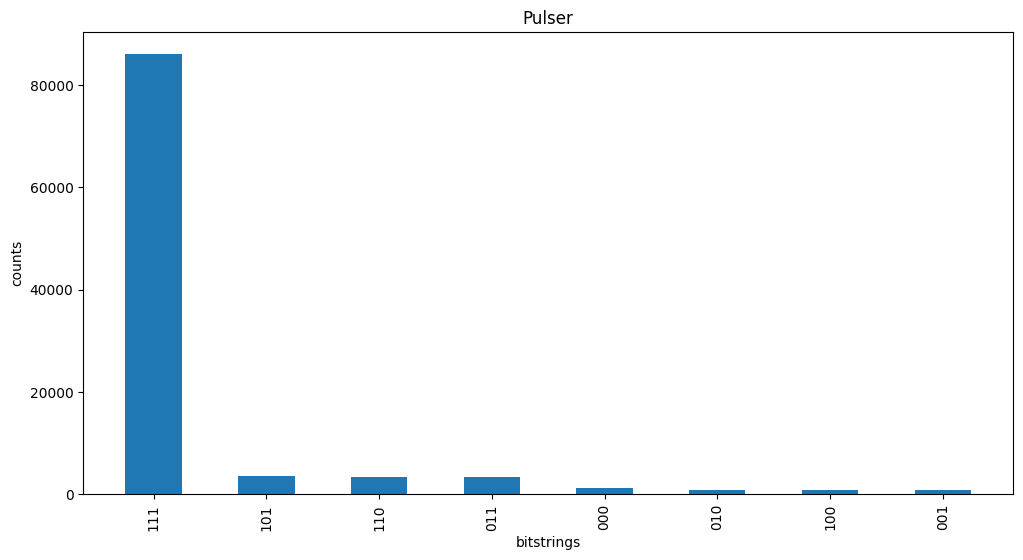

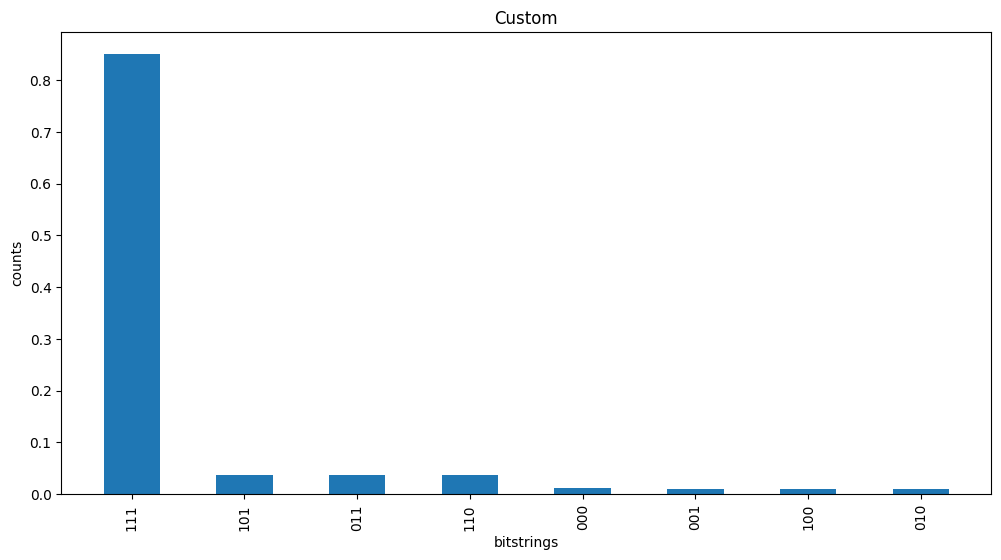

In [4]:
def probs_to_dict(probs, num_qubits):
    """
    주어진 확률 배열을 bitstring 별로 매핑하여 딕셔너리 형태로 반환합니다.

    :param probs: 확률 배열
    :param num_qubits: 큐비트 개수
    :return: bitstring 별 확률을 담은 딕셔너리
    """
    bitstrings = [np.binary_repr(i, num_qubits) for i in range(2 ** num_qubits)]
    return {bitstring: probs[i] for i, bitstring in enumerate(bitstrings)}


plot_distribution(count_dict,'Pulser')
plot_distribution(probs_to_dict(final_state_expectations,3),'Custom')

In [5]:
"""
또한 이러한 거리로 표현 가능한 QUBO이외에 모든 QUBO에 대해 general하게 시뮬레이션 가능하다.

그리고 이러한 simulation에 대해 실험적으로 parameter를 구해 QUBO가 들어올 때에 적절한 Pulse를 가하도록

Pulse를 구성하였다.
"""
from modules.data_process import add_constraint
import json
from modules.data_process import data_to_QUBO

# Load the dataset containing energy fluctuation matrices
with open(f"./data/GeoWindSunMatrices7by7.json", "r") as f:
    matrices_data = json.load(f)

# Define lambda (variance sensitivity factor) and hamming weight (number of selected power plants)
l = 20
hamming_weights = 4

# Convert variance data into QUBO format
QUBO_matrix = data_to_QUBO(np.array(matrices_data[1]), hamming_weights, l)

# Apply Soft Constraints to the QUBO matrix
n = len(QUBO_matrix)  # Number of energy sources
penalty = 1.5  # Penalty factor for constraint violations

# Generate a constraint matrix ensuring exactly 4 power plants are selected
qubo_const = QUBO_matrix + add_constraint(node_hamming_weights=[1] * n, hamming_weights=hamming_weights) * penalty

print(qubo_const) ## 이러한 QUBO는 거리공간에 구현 불가

[[-11.170754     1.63515136   1.79080053   1.63491475   1.58816453
    1.61776185   1.37573357]
 [  1.63515136 -11.25788288   1.6001001    1.58941122   1.55630631
    1.60291542   1.42488783]
 [  1.79080053   1.6001001  -11.16911356   1.61517058   1.59224502
    1.58845651   1.38150535]
 [  1.63491475   1.58941122   1.61517058 -11.16615467   1.73274604
    1.60074569   1.3446809 ]
 [  1.58816453   1.55630631   1.59224502   1.73274604 -11.20553887
    1.63680347   1.41077045]
 [  1.61776185   1.60291542   1.58845651   1.60074569   1.63680347
  -11.05413747   1.45584517]
 [  1.37573357   1.42488783   1.38150535   1.3446809    1.41077045
    1.45584517 -11.09935662]]


In [6]:
from modules.pulse_simulator import Pulse_simulation_fixed

bitstrings = [np.binary_repr(i, len(qubo_const)) for i in range(2 ** len(qubo_const))]
costs = []
# this takes exponential time with the dimension of the QUBO
for b in bitstrings:
    z = np.array(list(b), dtype=int)
    cost = z.T @ qubo_const @ z
    costs.append(cost)
zipped_cord = zip(bitstrings, costs)
sort_zipped = sorted(zipped_cord, key=lambda x: x[1])
print(sort_zipped[:5]) ## 성능 차이가 거의 없는 3번째 value까지 최적해


[('0110101', tensor(-26.80026179, requires_grad=True)), ('0111001', tensor(-26.78099576, requires_grad=True)), ('1100101', tensor(-26.75150426, requires_grad=True)), ('1101001', tensor(-26.6845889, requires_grad=True)), ('0101101', tensor(-26.61132752, requires_grad=True))]


In [7]:

pulse_sim = Pulse_simulation_fixed(qubo_const,step_time = 50) ## 펄스 시뮬레이션 객체 생성
## 시뮬레이션 결과
dev = qml.device("default.qubit", wires=len(qubo_const))
@qml.qnode(dev)
def circuit():
    pulse_sim.simulate_time_evolution()
    return qml.probs(wires=range(len(qubo_const)))
final_state_expectations = circuit()

constraint pass prob : 0.9756370440652281


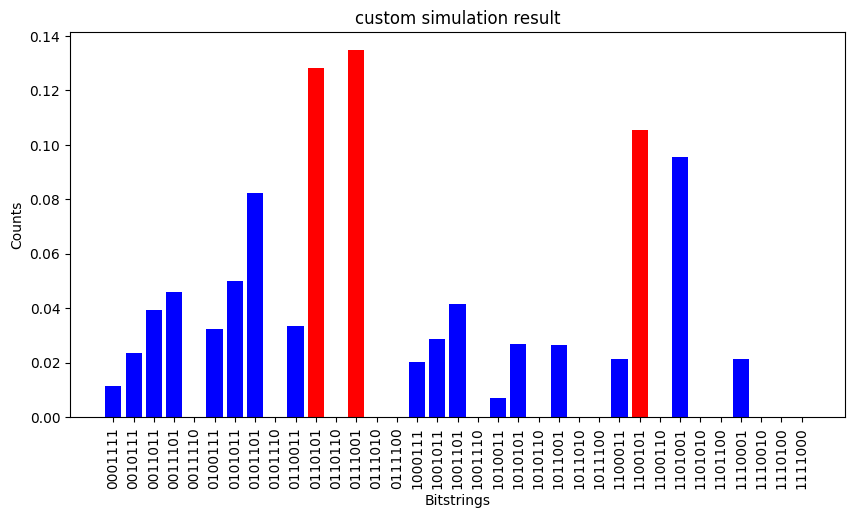

In [8]:
import matplotlib.pyplot as plt
from collections import Counter
def plot_bitstring_counts(input_data, hamming_weight,bitstring_counts,label):
    """
    입력된 bitstring 목록을 기반으로 주어진 bitstring_counts에서 해당 bitstring을
    빨간색 막대로 강조하고, 나머지는 파란색으로 표시하는 그래프를 생성합니다.

    :param input_data: List of tuples (bitstring, value)
    :param bitstring_counts: Dictionary (bitstring -> count)
    """
    import matplotlib.pyplot as plt

    # 빨간색으로 강조할 bitstring 목록 추출
    highlighted_strings = {bitstring for bitstring, _ in input_data}
    bit_str = {}
    # 데이터 준비
    for key in bitstring_counts.keys():
        count = 0
        for bit in key:
            if bit == "1":
                count+=1
        if count == hamming_weight:
            bit_str[key] = bitstring_counts[key]
    bitstrings = list(bit_str.keys())
    counts = np.array(list(bit_str.values()))/np.sum(list(bitstring_counts.values()))
    colors = ['red' if bitstring in highlighted_strings else 'blue' for bitstring in bitstrings]
    print(f'constraint pass prob : {np.sum(list(bit_str.values()))/np.sum(list(bitstring_counts.values()))}')
    # 막대 그래프 그리기
    plt.figure(figsize=(10, 5))
    plt.bar(bitstrings, counts, color=colors)
    plt.xlabel("Bitstrings")
    plt.ylabel("Counts")
    plt.title(label)
    plt.xticks(rotation=90)
    plt.show()

def probs_to_dict(probs, num_qubits):
    """
    주어진 확률 배열을 bitstring 별로 매핑하여 딕셔너리 형태로 반환합니다.

    :param probs: 확률 배열
    :param num_qubits: 큐비트 개수
    :return: bitstring 별 확률을 담은 딕셔너리
    """
    bitstrings = [np.binary_repr(i, num_qubits) for i in range(2 ** num_qubits)]
    return {bitstring: probs[i] for i, bitstring in enumerate(bitstrings)}


plot_bitstring_counts(sort_zipped[:3], hamming_weights,probs_to_dict(final_state_expectations,len(qubo_const)), "custom simulation result")

MWIS와 같은 General QUBO문제에 접근 가능한 방법을 이용하여 우리는 RL QAA를 제안한다.



RL QAA는 RL QAOA에서 QAOA layer를 adiabatice layer로 바꾼 모델이다.

여기에서 우리는 중성원자 플랫폼이 작동 시간이 긴 단점을 보완하기 위하여 Tree라는 구조를 가져왔다.

먼저 RL QAA는 Quantum layer의 학습없이 Quantum layer의 결과를 보고 edge를 선택하는 과정을 강화학습을 통해 학습하는 방법을 이용한다.

이러한 방법을 이용하기 때문에 Quantum layer의 결과값은 각 epoch과정에서 항상 같게 되는데, 그러한 점을 이용하여 한번 계산되었던 결과는 Quantum layer를 다시한번 호출하지

않고 저장되었던 데이터로 계산이 가능해진다.

그러므로 이 과정에서의 계산복잡도는 총 시나리오 수에 비례하게 되며, 이는 각 학습 과정에서 새로운 시나리오가 나올때마다 새로운 계산을 요구하게 된다.

이 방법을 사용하면 기존 RL QAOA보다 훨씬 더 계산 복잡도를 낮출 수 있는데, 기존 RL QAOA의 경우에는 각 계산 과정에서 QPU의 결과를 새롭게 갱신해야하므로

이러한 방법을 사용 할 수 없게되고 그러한 과정은 QPU의 더 많은 호출을 요구하게 된다.



In [10]:
from modules.rl_qaoa import RL_QAA
from modules.data_process import add_constraint,qubo_to_ising,ising_to_qubo

# Load the dataset containing energy fluctuation matrices
with open(f"./data/matrices8By8.json", "r") as f:
    matrices_data = json.load(f)

# Define lambda (variance sensitivity factor) and hamming weight (number of selected power plants)
l = 3
hamming_weights = 4

# Convert variance data into QUBO format
QUBO_matrix = data_to_QUBO(np.array(matrices_data[1]), hamming_weights, l)

# Apply Soft Constraints to the QUBO matrix
n = len(QUBO_matrix)  # Number of energy sources
penalty = 1.5  # Penalty factor for constraint violations

# Generate a constraint matrix ensuring exactly 4 power plants are selected
qubo_const = QUBO_matrix + add_constraint(node_hamming_weights=[1] * n, hamming_weights=2) * penalty
# Define the stopping condition for RL-QAOA (number of remaining nodes)
n_c = 2  # RL-QAOA halts when this number of nodes remains
# Define the initial edge temperature matrix for RL-QAOA training
b_vector = np.array([[25.0 * ((n - i) / 10 + 1)] * int(n**2) for i in range(n - n_c)])

# Initialize RL-QAOA with the constraint-enhanced QUBO
rl_qaa = RL_QAA(
    qubo_const, 
    n_c=5, 
    b_vector=b_vector, 
    learning_rate_init=0.50
)

rl_qaa.n_c = 5
correct_ans = rl_qaa.rqaoa_execute()
rl_qaa.n_c = 2

rl_qaa.RL_QAOA(10,20,correct_ans=float(correct_ans[2]))

Epoch 1/20: 100%|██████████| 10/10 [09:14<00:00, 55.46s/ episode]


  Probability of finding correct solution: 0.3000
  Average reward: -6.52301811613722
  Lowest reward obtained: -7.451295144514849
  Best state at lowest value: [ 1  1  1  1  1  1 -1 -1]
  number of nodes : 62


Epoch 6/20: 100%|██████████| 10/10 [04:35<00:00, 27.57s/ episode]


  Probability of finding correct solution: 0.5000
  Average reward: -7.023016840573125
  Lowest reward obtained: -7.449393000896501
  Best state at lowest value: [ 1  1  1  1  1 -1  1 -1]
  number of nodes : 296


Epoch 11/20: 100%|██████████| 10/10 [04:26<00:00, 26.61s/ episode]


  Probability of finding correct solution: 0.5000
  Average reward: -6.582420740026942
  Lowest reward obtained: -7.451295144514849
  Best state at lowest value: [ 1  1  1  1  1  1 -1 -1]
  number of nodes : 516


Epoch 16/20: 100%|██████████| 10/10 [03:44<00:00, 22.48s/ episode]


  Probability of finding correct solution: 0.2000
  Average reward: -6.999468055765426
  Lowest reward obtained: -7.443103631988511
  Best state at lowest value: [ 1  1 -1  1  1  1  1 -1]
  number of nodes : 727


Epoch 20/20: 100%|██████████| 10/10 [03:28<00:00, 20.81s/ episode]
